In [5]:
from pathlib import Path
import json
import seaborn as sns

# Samegame 2x3c3s2

In [6]:
mlp_single = json.load(Path("results/exp_mlp_samegame2x3c3s2_averaged/agent_eval.json").open())
mlp_dyad_a = json.load(Path("results/exp_dyad_mlp_samegame2x3c3s2_averaged/agent_a_eval.json").open())
mlp_dyad_b = json.load(Path("results/exp_dyad_mlp_samegame2x3c3s2_averaged/agent_b_eval.json").open())
mlp_dyad_sharing = json.load(Path("results/exp_dyad_mlp_samegame2x3c3s2_averaged/sharing_stats.json").open())

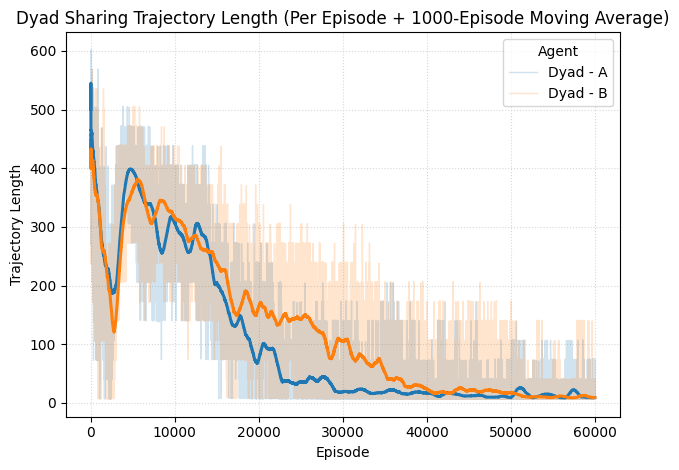

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_dyad_sharing_trajectory(mlp_dyad_sharing, window=1000):
    sharing_df = pd.DataFrame(mlp_dyad_sharing)
    sharing_df = sharing_df.sort_values("episode").copy()

    sharing_df["traj_a_len"] = sharing_df["traj_a_len"].astype(float)
    sharing_df["traj_b_len"] = sharing_df["traj_b_len"].astype(float)

    long_df = pd.concat(
        [
            sharing_df[["episode", "traj_a_len"]].rename(columns={"traj_a_len": "trajectory_length"}).assign(Agent="Dyad - A"),
            sharing_df[["episode", "traj_b_len"]].rename(columns={"traj_b_len": "trajectory_length"}).assign(Agent="Dyad - B"),
        ],
        ignore_index=True,
    ).sort_values(["Agent", "episode"])

    long_df["trajectory_length_ma1000"] = long_df.groupby("Agent")["trajectory_length"].transform(
        lambda s: s.rolling(window=window, min_periods=1).mean()
    )

    ax = sns.lineplot(
        data=long_df,
        x="episode",
        y="trajectory_length",
        hue="Agent",
        alpha=0.2,
        linewidth=1.0,
        legend=True,
    )

    sns.lineplot(
        data=long_df,
        x="episode",
        y="trajectory_length_ma1000",
        hue="Agent",
        linewidth=2.2,
        ax=ax,
        legend=False,
    )

    ax.set_xlabel("Episode")
    ax.set_ylabel("Trajectory Length")
    ax.set_title("Dyad Sharing Trajectory Length (Per Episode + 1000-Episode Moving Average)")
    ax.grid(True, color="lightgrey", linestyle=":", linewidth=0.8, alpha=0.9)
    plt.tight_layout()

plot_dyad_sharing_trajectory(mlp_dyad_sharing)

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_agent_performance(mlp_single, mlp_dyad_a, mlp_dyad_b):
    # Extract episode, mean length, and SEM length for each agent
    mlp_single_df = pd.DataFrame(
        [(d['episode'], d['avg_length'], d.get('sem_length', 0.0)) for d in mlp_single],
        columns=['episode', 'avg_length', 'sem_length']
    )
    mlp_single_df['Agent'] = 'Single Learning'

    mlp_dyad_a_df = pd.DataFrame(
        [(d['episode'], d['avg_length'], d.get('sem_length', 0.0)) for d in mlp_dyad_a],
        columns=['episode', 'avg_length', 'sem_length']
    )
    mlp_dyad_a_df['Agent'] = 'Dyad - A'

    mlp_dyad_b_df = pd.DataFrame(
        [(d['episode'], d['avg_length'], d.get('sem_length', 0.0)) for d in mlp_dyad_b],
        columns=['episode', 'avg_length', 'sem_length']
    )
    mlp_dyad_b_df['Agent'] = 'Dyad - B'

    # Combine into a single dataframe
    combined_df = pd.concat([mlp_single_df, mlp_dyad_a_df, mlp_dyad_b_df], ignore_index=True)

    # Mean lines
    ax = sns.lineplot(
        data=combined_df,
        x='episode',
        y='avg_length',
        hue='Agent',
        errorbar=None
    )

    # SEM band around each mean line
    for line, (agent, group) in zip(ax.lines, combined_df.groupby('Agent', sort=False)):
        group = group.sort_values('episode')
        x = group['episode'].to_numpy()
        y = group['avg_length'].to_numpy()
        sem = group['sem_length'].to_numpy()
        lower = np.clip(y - sem, 0.0, None)
        upper = y + sem
        ax.fill_between(x, lower, upper, color=line.get_color(), alpha=0.18)

    ax.set_ylabel('Average Solution Length')
    ax.set_xlabel('Learning Episode')
    ax.set_title('Samegame 2x3c3s2 - MLP Agents')
    ax.grid(True, color='lightgrey', linestyle=':', linewidth=0.8, alpha=0.9)
    plt.tight_layout()

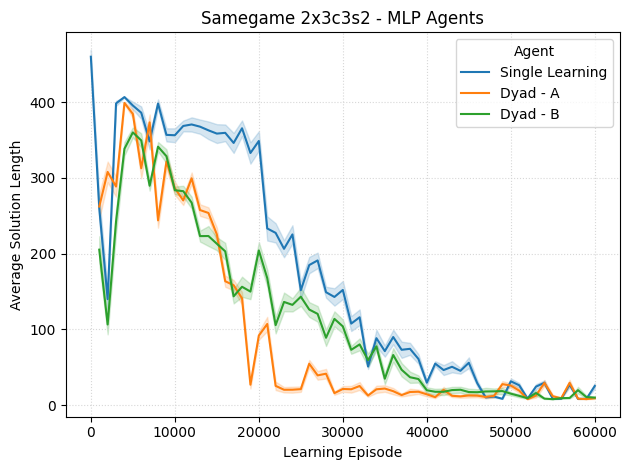

In [9]:
plot_agent_performance(mlp_single, mlp_dyad_a, mlp_dyad_b)

Now plot performance of the agents on the 2x3c3s2 game, where the dyad agents are accepting **all** Transitions.

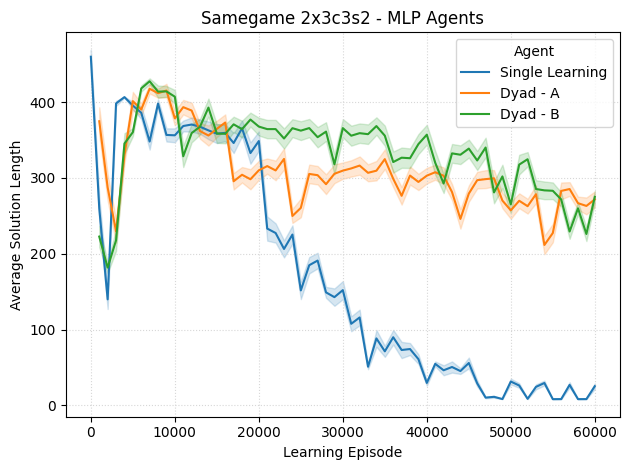

In [10]:
mlp_single = json.load(Path("results/exp_mlp_samegame2x3c3s2_averaged/agent_eval.json").open())
mlp_dyad_a = json.load(Path("results/exp_dyad_mlp_accept_all_samegame2x3c3s2_averaged/agent_a_eval.json").open())
mlp_dyad_b = json.load(Path("results/exp_dyad_mlp_accept_all_samegame2x3c3s2_averaged/agent_b_eval.json").open())

plot_agent_performance(mlp_single, mlp_dyad_a, mlp_dyad_b)

## Additional experiments

In [39]:
mlp_single_large_eps = json.load(Path("results_new/exp_mlp_samegame2x3c3s2_large_eps/agent_eval.json").open())

cnn_mlp_dyad_a = json.load(Path("results_new/exp_dyad_cnn_mlp_samegame2x3c3s2_large_eps1/agent_a_eval.json").open())
cnn_mlp_dyad_b = json.load(Path("results_new/exp_dyad_cnn_mlp_samegame2x3c3s2_large_eps1/agent_b_eval.json").open())
cnn_mlp_dyad_sharing = json.load(Path("results_new/exp_dyad_cnn_mlp_samegame2x3c3s2_large_eps1/sharing_stats.json").open())

pooling_cnn_mlp_dyad_a = json.load(Path("results_new/dyad_cnn_mlp_with_pooling_large_image_normal_eps/agent_a_eval.json").open())
pooling_cnn_mlp_dyad_b = json.load(Path("results_new/dyad_cnn_mlp_with_pooling_large_image_normal_eps/agent_b_eval.json").open())
pooling_cnn_mlp_dyad_sharing = json.load(Path("results_new/dyad_cnn_mlp_with_pooling_large_image_normal_eps/sharing_stats.json").open())


In [40]:
def plot_agent_performance_two(mlp_single, mlp_single_large_eps, legend_a, legend_b, title_plot): #, mlp_dyad_b):
    # Extract episode, mean length, and SEM length for each agent
    mlp_single_df = pd.DataFrame(
        [(d['episode'], d['avg_length'], d.get('sem_length', 0.0)) for d in mlp_single],
        columns=['episode', 'avg_length', 'sem_length']
    )
    mlp_single_df['Agent'] = legend_a

    mlp_single_large_eps_df = pd.DataFrame(
        [(d['episode'], d['avg_length'], d.get('sem_length', 0.0)) for d in mlp_single_large_eps],
        columns=['episode', 'avg_length', 'sem_length']
    )
    mlp_single_large_eps_df['Agent'] = legend_b

    # mlp_dyad_b_df = pd.DataFrame(
    #     [(d['episode'], d['avg_length'], d.get('sem_length', 0.0)) for d in mlp_dyad_b],
    #     columns=['episode', 'avg_length', 'sem_length']
    # )
    # mlp_dyad_b_df['Agent'] = 'Dyad - B'

    # Combine into a single dataframe
    # combined_df = pd.concat([mlp_single_df, mlp_dyad_a_df, mlp_dyad_b_df], ignore_index=True)
    combined_df = pd.concat([mlp_single_df, mlp_single_large_eps_df], ignore_index=True)

    # Mean lines
    ax = sns.lineplot(
        data=combined_df,
        x='episode',
        y='avg_length',
        hue='Agent',
        errorbar=None
    )

    # SEM band around each mean line
    for line, (agent, group) in zip(ax.lines, combined_df.groupby('Agent', sort=False)):
        group = group.sort_values('episode')
        x = group['episode'].to_numpy()
        y = group['avg_length'].to_numpy()
        sem = group['sem_length'].to_numpy()
        lower = np.clip(y - sem, 0.0, None)
        upper = y + sem
        ax.fill_between(x, lower, upper, color=line.get_color(), alpha=0.18)

    ax.set_ylabel('Average Solution Length')
    ax.set_xlabel('Learning Episode')
    ax.set_title(title_plot)
    ax.grid(True, color='lightgrey', linestyle=':', linewidth=0.8, alpha=0.9)
    plt.tight_layout()

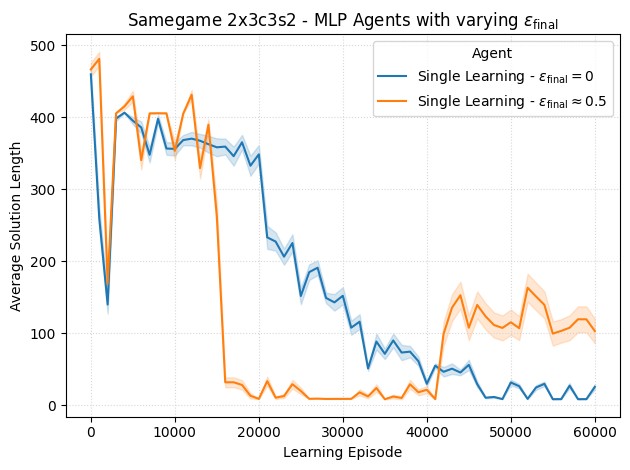

In [41]:

plot_agent_performance_two(mlp_single, mlp_single_large_eps, r'Single Learning - $\epsilon_\mathrm{final}=0$', r'Single Learning - $\epsilon_\mathrm{final} \approx 0.5$', r'Samegame 2x3c3s2 - MLP Agents with varying $\epsilon_\mathrm{final}$')

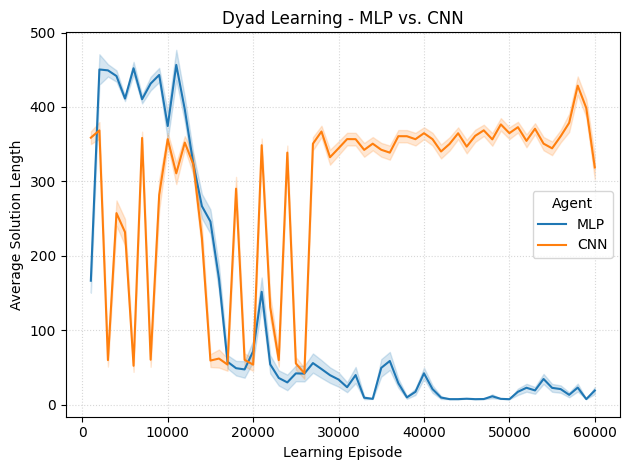

In [42]:

plot_agent_performance_two(cnn_mlp_dyad_a, cnn_mlp_dyad_b, "MLP", "CNN", "Dyad Learning - MLP vs. CNN")

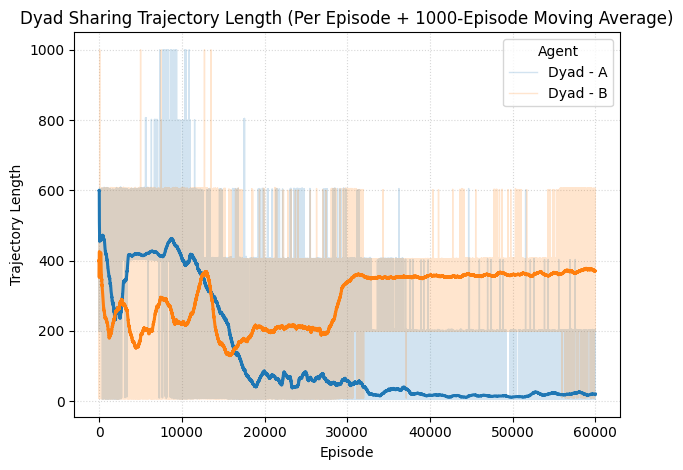

In [43]:
plot_dyad_sharing_trajectory(cnn_mlp_dyad_sharing)

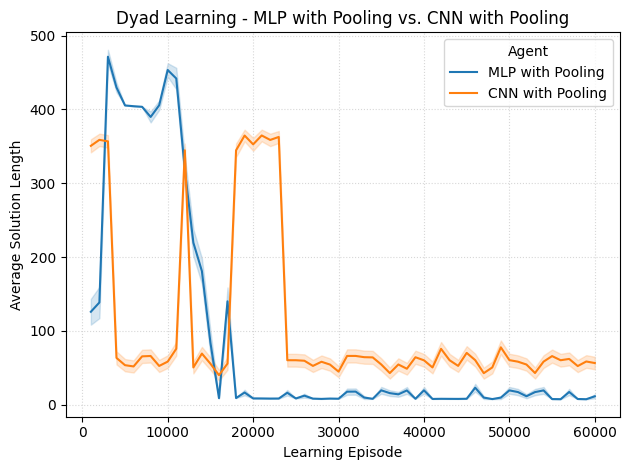

In [44]:
plot_agent_performance_two(pooling_cnn_mlp_dyad_a, pooling_cnn_mlp_dyad_b, "MLP with Pooling", "CNN with Pooling", "Dyad Learning - MLP with Pooling vs. CNN with Pooling")

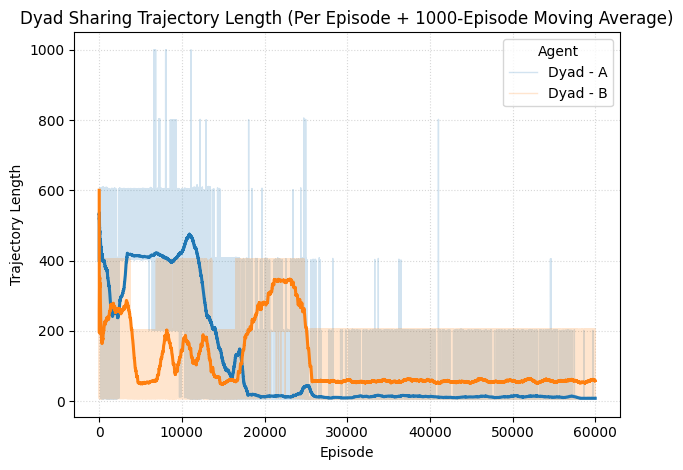

In [45]:
plot_dyad_sharing_trajectory(pooling_cnn_mlp_dyad_sharing)